# Real Data Resolution Sensitivity — 2024-07-03

**Goal**: Fit HybridVecchia on real GEMS TCO data at 4 observation densities
(x8=coarsest → x1=finest, via maxmin-order thinning) × 2 smooth values.
Track how parameter estimates change as data volume increases.

**Design**: 4 resolutions × 2 smooth = 8 fits

| fit_smooth | R=8 | R=4 | R=2 | R=1 |
|---|---|---|---|---|
| 0.5 | ✓ | ✓ | ✓ | ✓ |
| 1.5 | ✓ | ✓ | ✓ | ✓ |

**Hybrid Vecchia conditioning sets** (same as simulation notebook):
- Set A (t):   spatial NN 20
- Set B (t-1): anchor(1) + local NN(16) + upstream shifted NN(2)
- Set C (t-2): anchor(1) + local NN(12) + upstream shifted×2 NN(2)

**Thinning**: after MaxMin ordering, take every Rth row.
R=8 ≈ 2k obs total; R=1 ≈ 140k obs total.

In [1]:
import sys, time, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, "/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO import orderings as _orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_vecchia_hybrid import HybridVecchiaFit

print('torch:', torch.__version__)
print('device: cpu (Mac)')

torch: 2.5.1
device: cpu (Mac)


In [2]:
# ── experiment config ──────────────────────────────────────────────────
DEVICE = torch.device('cpu')
DTYPE  = torch.float64

YEAR         = '2023'
MONTH        = 7
DAY_IDX_LIST = [7,8,9]        # 0-based; e.g. [0,1,2] = July 1,2,3
                           # DATE_STR auto-generated per day in fitting loop
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

# ── Vecchia hyperparams ────────────────────────────────────────────────
MM_COND_NUMBER  = 100
NHEADS          = 100
LIMIT_A         = 20
LIMIT_B_LOCAL   = 16
LIMIT_C_LOCAL   = 12
DAILY_STRIDE    = 2
LAG1_FRESH      = 2
LAG2_FRESH      = 2
LAG1_LON_OFFSET = 0.063

# ── optimizer ─────────────────────────────────────────────────────────
LBFGS_LR    = 1.0
LBFGS_STEPS = 10
LBFGS_EVAL  = 20
LBFGS_HIST  = 10

# ── experiment axes ───────────────────────────────────────────────────
FIT_SMOOTHS      = [0.5, 1.5]
RESOLUTION_MULTS = [8, 4, 2, 1]   # thinning factor; 8=coarsest, 1=finest

# ── initial values ────────────────────────────────────────────────────
INIT_DICT = {
    'sigmasq':    13.059,
    'range_lat':  0.2,
    'range_lon':  0.25,
    'range_time': 1.5,
    'advec_lat':  0.0218,
    'advec_lon':  -0.1689,
    'nugget':     0.247,
}

P_LABELS = ['sigmasq', 'range_lat', 'range_lon', 'range_time',
            'advec_lat', 'advec_lon', 'nugget']
P_DISP   = [r'$\sigma^2$ (sigmasq)', 'range_lat', 'range_lon', 'range_time',
            r'$\alpha_{lat}$', r'$\alpha_{lon}$', 'nugget']

print(f'Config loaded.  DAY_IDX_LIST={DAY_IDX_LIST}')

Config loaded.  DAY_IDX_LIST=[7, 8, 9]


In [3]:
# ── parameter reparametrization (same as simulation notebook) ──────────
def phys_to_log(d):
    """Physical params → log-reparametrized [logφ1, logφ2, logφ3, logφ4, advec_lat, advec_lon, log_nugget]."""
    phi2 = 1.0 / d['range_lon']
    phi1 = d['sigmasq'] * phi2
    phi3 = (d['range_lon'] / d['range_lat']) ** 2
    phi4 = (d['range_lon'] / d['range_time']) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            d['advec_lat'], d['advec_lon'], np.log(d['nugget'])]


def backmap_params(out_params):
    """Log-reparametrized → physical."""
    p    = [float(x.item() if isinstance(x, torch.Tensor) else x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        'sigmasq':    np.exp(p[0]) / phi2,
        'range_lat':  rlon / phi3 ** 0.5,
        'range_lon':  rlon,
        'range_time': rlon / phi4 ** 0.5,
        'advec_lat':  p[4],
        'advec_lon':  p[5],
        'nugget':     np.exp(p[6]),
    }


INIT_LOG = phys_to_log(INIT_DICT)
print('Initial log-params:', [f'{v:.4f}' for v in INIT_LOG])

Initial log-params: ['3.9558', '1.3863', '0.4463', '-3.5835', '0.0218', '-0.1689', '-1.3984']


In [4]:
# ── load full month data (done once — expensive) ─────────────────────
loader = load_data_dynamic_processed(config.mac_data_load_path)

df_map, ord_mm, nns_map_full, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=MM_COND_NUMBER,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=False,
)

sorted_df_keys = sorted(df_map.keys())
print(f'Monthly mean TCO: {monthly_mean:.4f}')
print(f'Total time slots in month: {len(sorted_df_keys)}')

--- Global Monthly Mean for 2023-7: 249.7131 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
Monthly mean TCO: 249.7131
Total time slots in month: 248


In [5]:
# ── extract grid coordinates (same for all days — grid structure is fixed) ──
first_df = df_map[sorted_df_keys[0]].iloc[ord_mm].reset_index(drop=True)
grid_coords_ordered = first_df[['Latitude', 'Longitude']].values.astype(np.float64)
n_grid_full = len(grid_coords_ordered)

print(f'Grid: {n_grid_full:,} cells')
print(f'lat range: {grid_coords_ordered[:,0].min():.2f} – {grid_coords_ordered[:,0].max():.2f}')
print(f'lon range: {grid_coords_ordered[:,1].min():.2f} – {grid_coords_ordered[:,1].max():.2f}')

Grid: 18,126 cells
lat range: -2.97 – 2.00
lon range: 121.05 – 131.00


In [6]:
# ── precompute NNS per resolution (same for all days — depends only on grid) ──
# Thinning: first round(N/R) rows in maxmin order (low-freq → high-freq).

nns_setups = {}

for R in RESOLUTION_MULTS:
    n_thin              = round(n_grid_full / R)
    thin_idx            = np.arange(0, n_thin)
    thin_spatial_coords = grid_coords_ordered[thin_idx]       # (lat, lon)
    thin_coords_lonlat  = thin_spatial_coords[:, ::-1].copy() # (lon, lat) for find_nns_l2

    nns_thin = _orderings.find_nns_l2(locs=thin_coords_lonlat, max_nn=MM_COND_NUMBER)

    nns_setups[R] = {
        'thin_idx':       thin_idx,
        'nns':            nns_thin,
        'spatial_coords': thin_spatial_coords,
        'n_grid':         n_thin,
    }
    print(f'R={R:2d}: n_grid={n_thin:6,}  nns_shape={nns_thin.shape}')

print('NNS precompute done.')

R= 8: n_grid= 2,266  nns_shape=(2266, 100)
R= 4: n_grid= 4,532  nns_shape=(4532, 100)
R= 2: n_grid= 9,063  nns_shape=(9063, 100)
R= 1: n_grid=18,126  nns_shape=(18126, 100)
NNS precompute done.



DAY 20230708:  2023_07_y23m07day08_hm00:53  …  2023_07_y23m07day08_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  17,871
  R= 4: n_grid= 4,532  valid_obs=  35,780
  R= 2: n_grid= 9,063  valid_obs=  71,640
  R= 1: n_grid=18,126  valid_obs= 143,238

  Fitting: smooth=0.5  R=8  [n_obs=17,871]
Pre-computing HybridVecchia (smooth=0.5) [A=20, AB=39, ABC=54, B=local16+fresh2, C=local12+fresh2, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.5060] [SetC=True] Done. (Heads=774, Tails A/AB/ABC=2142/2141/12814)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.588227 ---
  Param 0: Value=3.3358, Grad=0.037637329193771295
  Param 1: Value=0.7790, Grad=-0.007711537786241637
  Param 2: Value=1.4862, Grad=0.014187915996080743
  Param 3: Value=-2.1224, Grad=0.003323634584732114
  Param 4: Value=-0.1183, Grad=-0.04829980019220459
  Param 5: Value=-0.1684, Grad=0.007777573148654682
  Param 6: Value=0.5595, Grad=-0.0009591027710792744
  Max Abs Grad: 4.829980e-02
--------------------

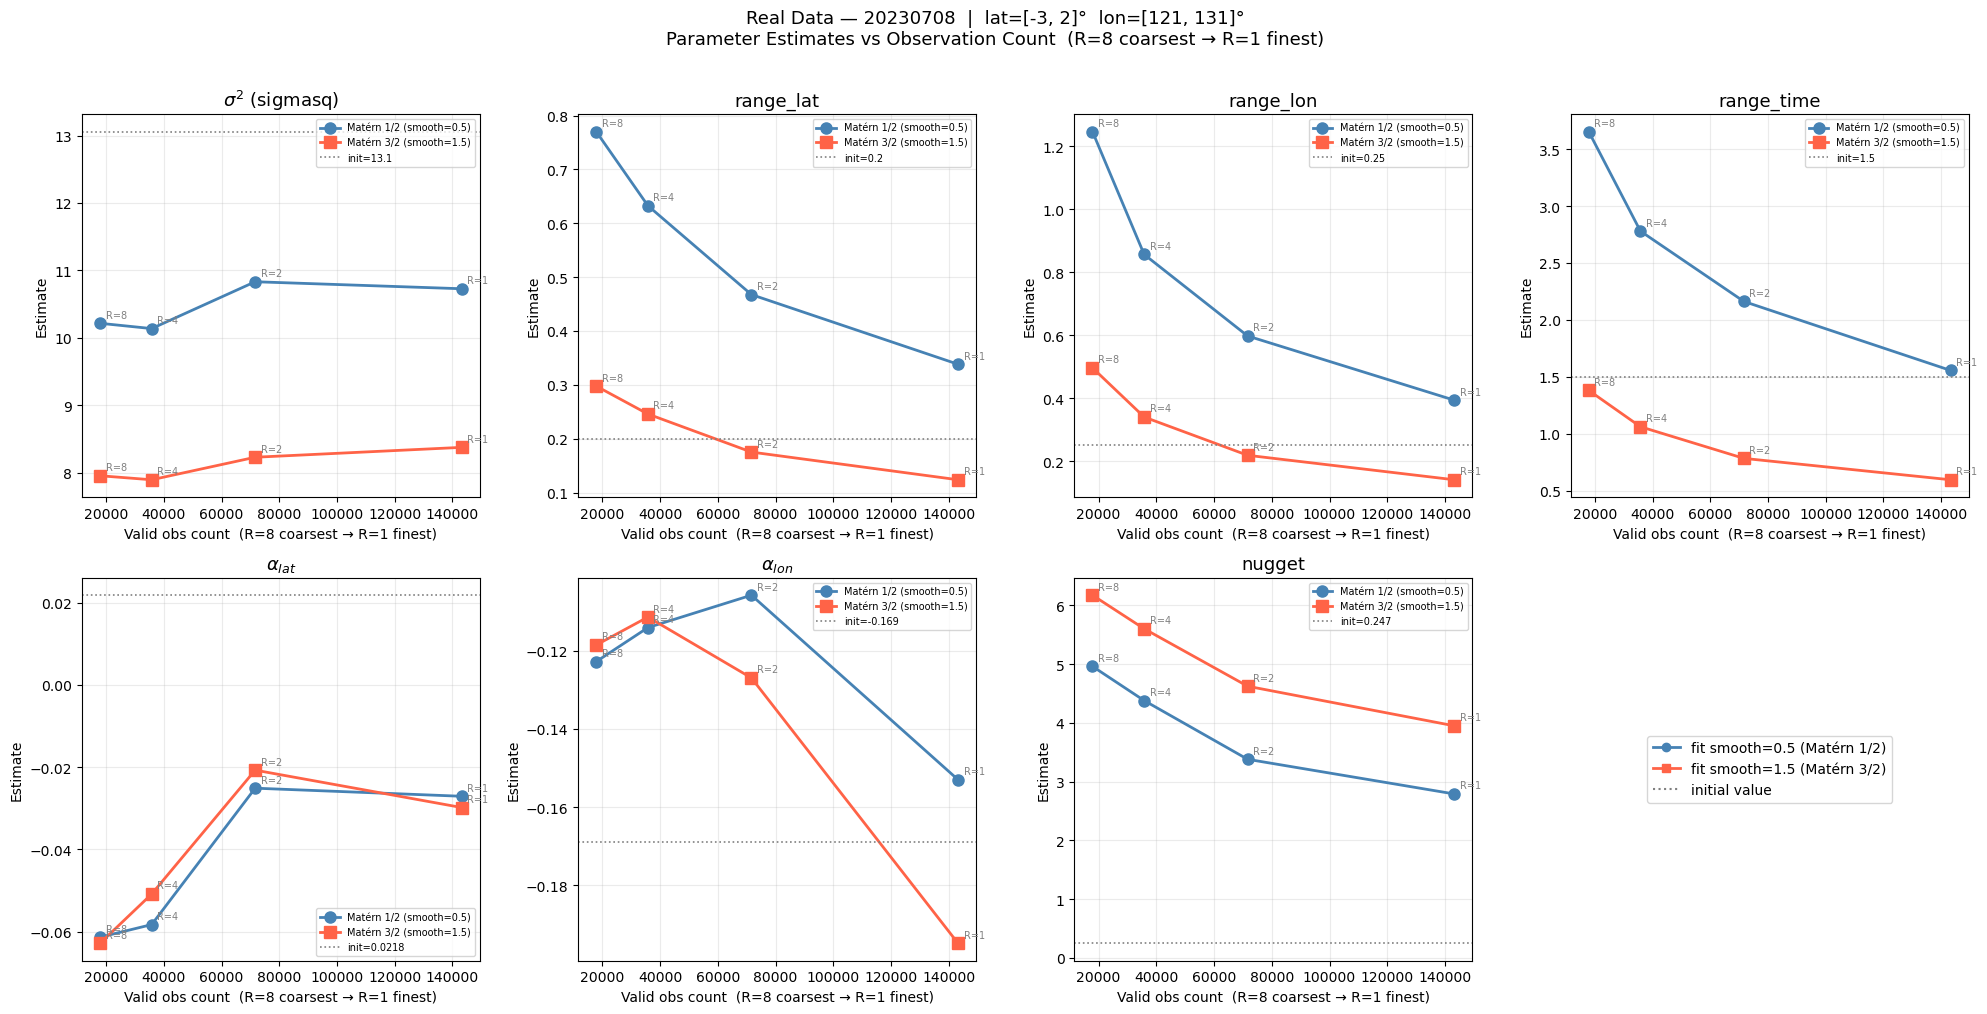

Saved: real_data_param_trajectories_20230708.png

DAY 20230709:  2023_07_y23m07day09_hm00:53  …  2023_07_y23m07day09_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  15,952
  R= 4: n_grid= 4,532  valid_obs=  31,737
  R= 2: n_grid= 9,063  valid_obs=  63,841
  R= 1: n_grid=18,126  valid_obs= 127,665

  Fitting: smooth=0.5  R=8  [n_obs=15,952]
Pre-computing HybridVecchia (smooth=0.5) [A=20, AB=39, ABC=54, B=local16+fresh2, C=local12+fresh2, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.3982] [SetC=True] Done. (Heads=691, Tails A/AB/ABC=1903/1892/11466)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.579350 ---
  Param 0: Value=3.6675, Grad=0.01225091082722419
  Param 1: Value=1.0200, Grad=-0.004563593840694238
  Param 2: Value=0.8590, Grad=0.0022452011370094186
  Param 3: Value=-2.8279, Grad=0.0012137974656868395
  Param 4: Value=0.0296, Grad=0.0018495137150038587
  Param 5: Value=-0.1806, Grad=-0.009638733043564773
  Param 6: Value=-0.8074, Grad=-0.00100265777507524

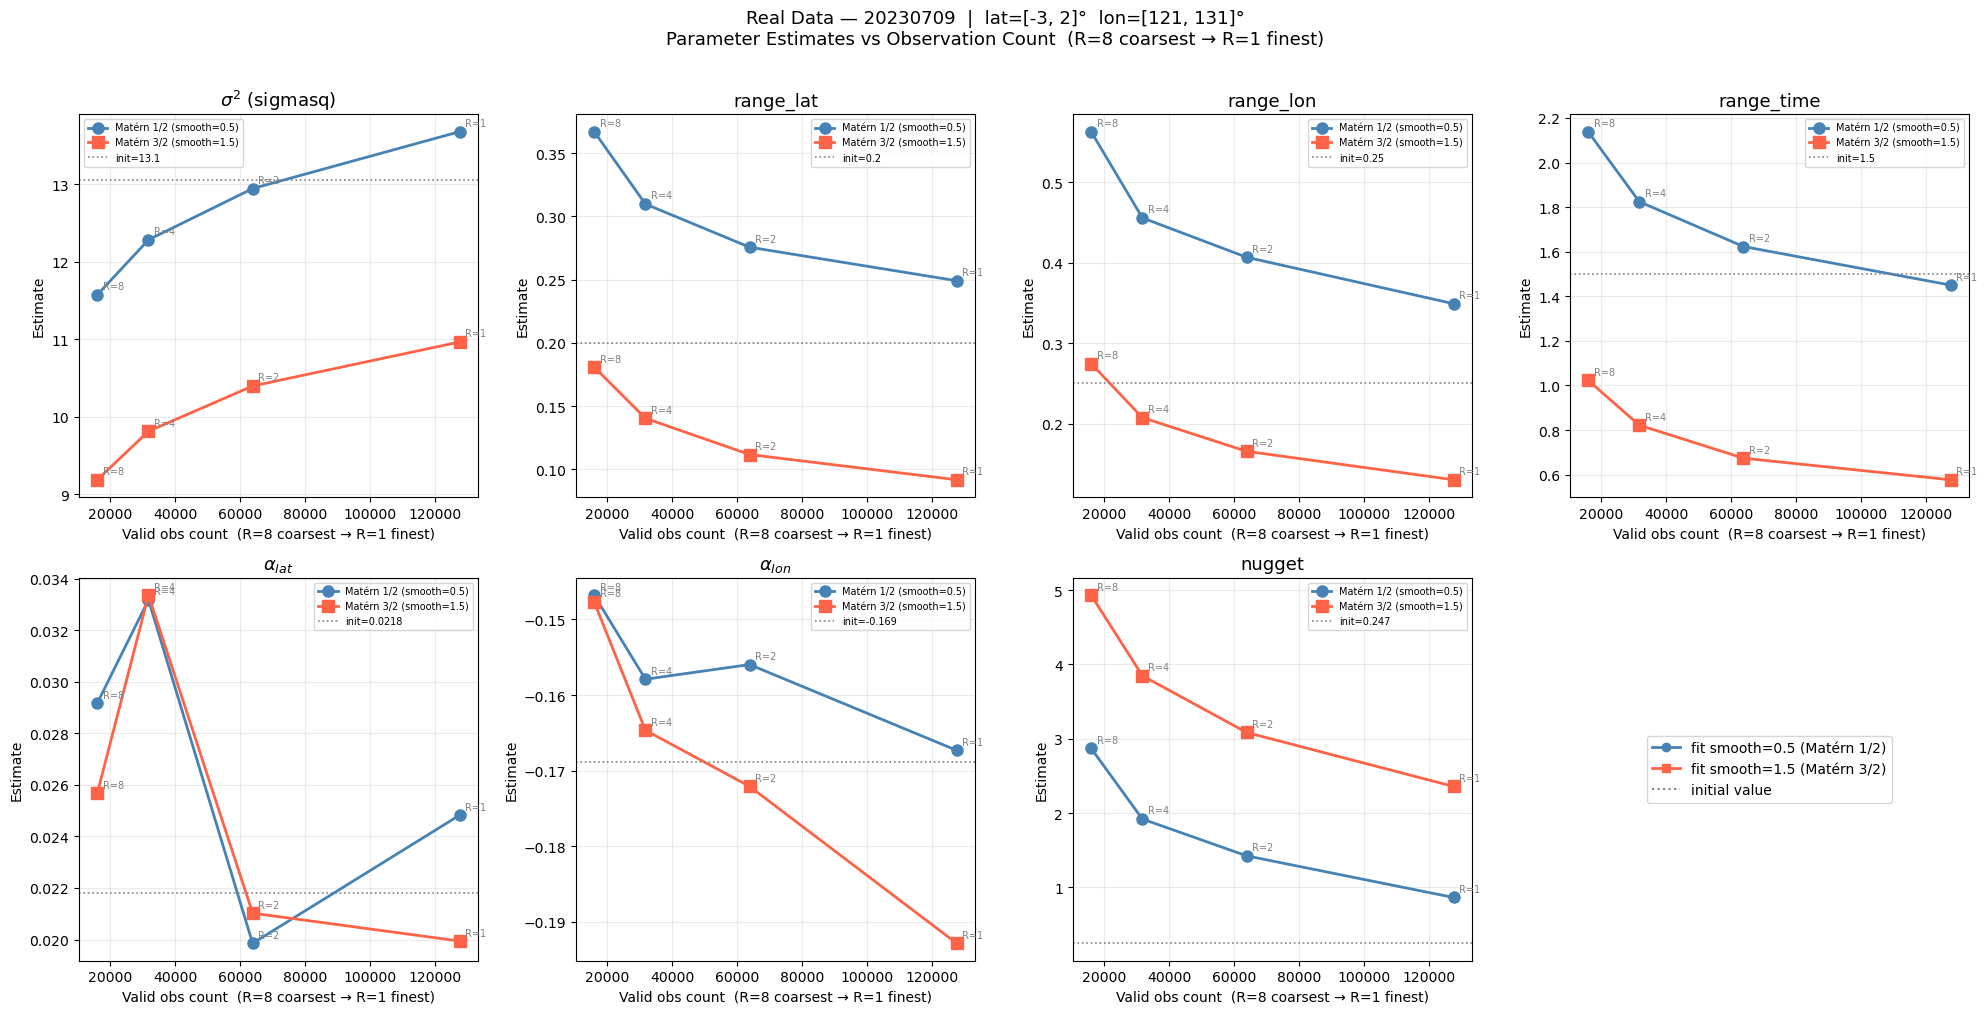

Saved: real_data_param_trajectories_20230709.png

DAY 20230710:  2023_07_y23m07day10_hm00:53  …  2023_07_y23m07day10_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  15,873
  R= 4: n_grid= 4,532  valid_obs=  31,770
  R= 2: n_grid= 9,063  valid_obs=  63,732
  R= 1: n_grid=18,126  valid_obs= 127,023

  Fitting: smooth=0.5  R=8  [n_obs=15,873]
Pre-computing HybridVecchia (smooth=0.5) [A=20, AB=39, ABC=54, B=local16+fresh2, C=local12+fresh2, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.6330] [SetC=True] Done. (Heads=694, Tails A/AB/ABC=1904/1879/11396)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.538041 ---
  Param 0: Value=3.0331, Grad=0.03542847848176476
  Param 1: Value=0.0777, Grad=-0.010676643625713642
  Param 2: Value=1.4058, Grad=0.014062434189812734
  Param 3: Value=-2.3640, Grad=0.0029846230702374977
  Param 4: Value=0.0445, Grad=-0.020849631881360242
  Param 5: Value=-0.2328, Grad=0.0056049081446811755
  Param 6: Value=0.4513, Grad=-0.0006139807242300431

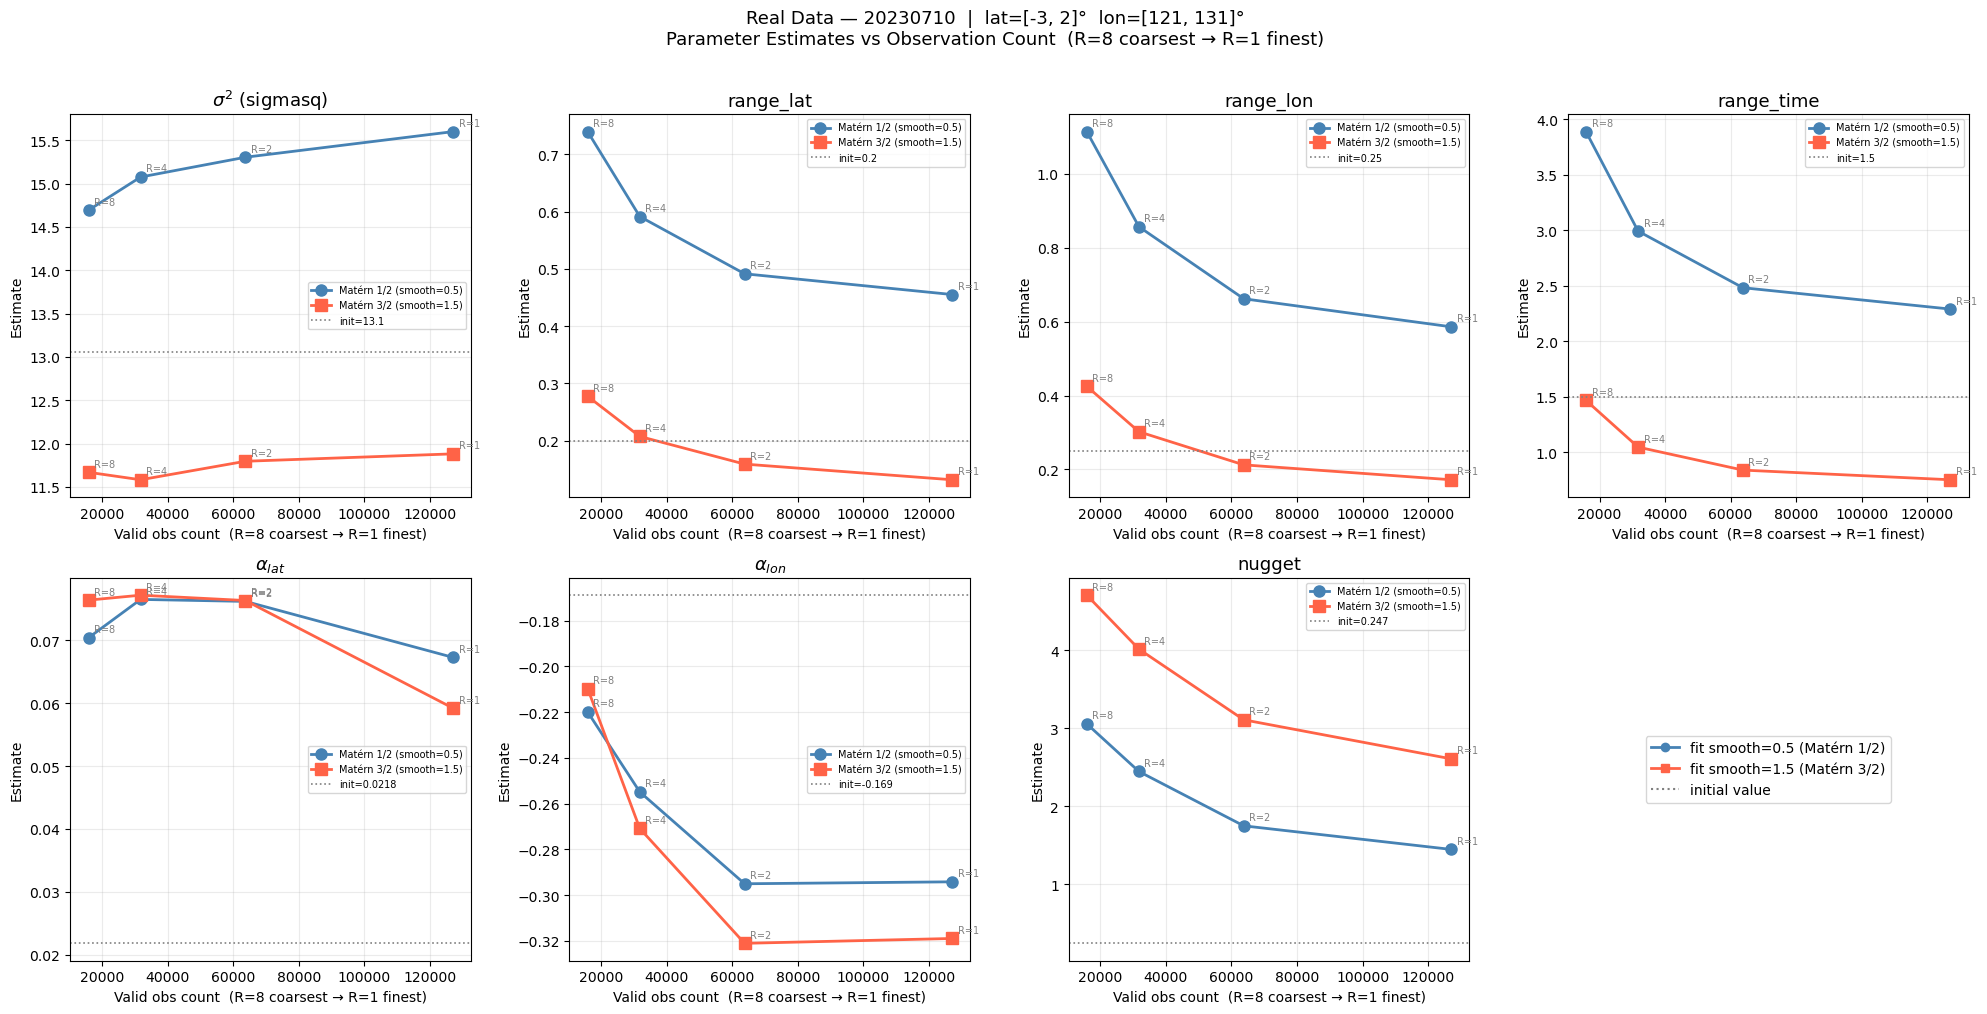

Saved: real_data_param_trajectories_20230710.png

All done. 24 total fits across 3 day(s).


In [7]:
# ── fitting loop: per day × 4 resolutions × 2 smooth ─────────────────
# Each day: load_working_data → thin → fit → plot → save PNG with DATE_STR.

COLOR        = {0.5: 'steelblue', 1.5: 'tomato'}
MK           = {0.5: 'o',         1.5: 's'}
SMOOTH_LABEL = {0.5: 'Matérn 1/2 (smooth=0.5)', 1.5: 'Matérn 3/2 (smooth=1.5)'}

all_results = []

for DAY_IDX in DAY_IDX_LIST:
    DATE_STR     = f"{YEAR}{MONTH:02d}{DAY_IDX+1:02d}"
    hour_indices = [DAY_IDX * 8, (DAY_IDX + 1) * 8]

    # ── load this day's data ──────────────────────────────────────────
    full_day_map, _ = loader.load_working_data(
        df_map, monthly_mean, hour_indices,
        ord_mm=ord_mm, dtype=DTYPE, keep_ori=True,
    )
    day_df_keys = sorted_df_keys[hour_indices[0]:hour_indices[1]]
    print(f'\n{"="*65}')
    print(f'DAY {DATE_STR}:  {day_df_keys[0]}  …  {day_df_keys[-1]}')

    # ── build per-resolution setups (thin_map reuses precomputed NNS) ─
    setups = {}
    for R in RESOLUTION_MULTS:
        ns       = nns_setups[R]
        thin_map = {k: v[ns['thin_idx']] for k, v in full_day_map.items()}
        n_valid  = sum(int((~torch.isnan(v[:, 2])).sum()) for v in thin_map.values())
        setups[R] = {**ns, 'thin_map': thin_map, 'n_valid': n_valid}
        print(f'  R={R:2d}: n_grid={ns["n_grid"]:6,}  valid_obs={n_valid:8,}')

    # ── fit: 4 resolutions × 2 smooth = 8 fits ───────────────────────
    results = []
    INIT_LOG = phys_to_log(INIT_DICT)

    for fs in FIT_SMOOTHS:
        for R in RESOLUTION_MULTS:
            setup = setups[R]
            tag   = f'smooth={fs}  R={R}  [n_obs={setup["n_valid"]:,}]'
            print(f'\n  Fitting: {tag}')

            params = [
                torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True)
                for v in INIT_LOG
            ]

            model = HybridVecchiaFit(
                smooth=fs,
                input_map={k: v.to(DEVICE) for k, v in setup['thin_map'].items()},
                nns_map=setup['nns'],
                mm_cond_number=MM_COND_NUMBER,
                nheads=NHEADS,
                limit_A=LIMIT_A,
                limit_B_local=LIMIT_B_LOCAL,
                limit_C_local=LIMIT_C_LOCAL,
                daily_stride=DAILY_STRIDE,
                spatial_coords=setup['spatial_coords'],
                lag1_lon_offset=LAG1_LON_OFFSET,
                lag1_fresh_count=LAG1_FRESH,
                lag2_fresh_count=LAG2_FRESH,
            )
            model.precompute_conditioning_sets()

            optimizer = model.set_optimizer(
                params, lr=LBFGS_LR,
                max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL,
                history_size=LBFGS_HIST,
            )
            t0 = time.time()
            out, fit_iter = model.fit_vecc_lbfgs(
                params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5,
            )
            elapsed = time.time() - t0

            loss = float(out[-1])
            est  = backmap_params(out)
            print(f'    loss={loss:.4f}  elapsed={elapsed:.1f}s  steps={fit_iter+1}')

            results.append({
                'date_str':    DATE_STR,
                'day_idx':     DAY_IDX,
                'fit_smooth':  fs,
                'R':           R,
                'n_obs_total': setup['n_valid'],
                'n_grid':      setup['n_grid'],
                'loss':        loss,
                'fit_steps':   fit_iter + 1,
                'elapsed_s':   round(elapsed, 1),
                **{f'est_{k}': est[k] for k in P_LABELS},
            })
            del model
            gc.collect()

    df_day = pd.DataFrame(results)
    all_results.append(df_day)

    # ── plot for this day ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, (param, plabel) in enumerate(zip(P_LABELS, P_DISP)):
        ax   = axes[i]
        init = INIT_DICT[param]

        for fs in FIT_SMOOTHS:
            sub = df_day[df_day.fit_smooth == fs].sort_values('n_obs_total')
            ax.plot(
                sub['n_obs_total'], sub[f'est_{param}'],
                color=COLOR[fs], marker=MK[fs], ms=8, lw=2,
                label=SMOOTH_LABEL[fs],
            )
            for _, row in sub.iterrows():
                ax.annotate(
                    f"R={int(row.R)}",
                    (row['n_obs_total'], row[f'est_{param}']),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=7, color='grey',
                )

        ax.axhline(init, color='grey', ls=':', lw=1.2, label=f'init={init:.3g}')
        ax.set_title(plabel, fontsize=13)
        ax.set_xlabel('Valid obs count  (R=8 coarsest → R=1 finest)')
        ax.set_ylabel('Estimate')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.25)

    axes[-1].set_visible(False)
    import matplotlib.lines as mlines
    legend_entries = [
        mlines.Line2D([], [], color=COLOR[0.5], marker='o', lw=2, label='fit smooth=0.5 (Matérn 1/2)'),
        mlines.Line2D([], [], color=COLOR[1.5], marker='s', lw=2, label='fit smooth=1.5 (Matérn 3/2)'),
        mlines.Line2D([], [], color='grey',    ls=':',     lw=1.5, label='initial value'),
    ]
    axes[-1].legend(handles=legend_entries, loc='center', fontsize=10, frameon=True)
    axes[-1].set_visible(True)
    axes[-1].axis('off')

    fig.suptitle(
        f'Real Data — {DATE_STR}  |  lat={LAT_RANGE}°  lon={LON_RANGE}°\n'
        'Parameter Estimates vs Observation Count  (R=8 coarsest → R=1 finest)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    fname = f'real_data_param_trajectories_{DATE_STR}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

df = pd.concat(all_results, ignore_index=True)
print(f'\nAll done. {len(df)} total fits across {len(DAY_IDX_LIST)} day(s).')

In [8]:
# ── numerical summary across all days ────────────────────────────────
print('=' * 75)
print(f'REAL DATA RESOLUTION SENSITIVITY — days: {[f"{YEAR}{MONTH:02d}{d+1:02d}" for d in DAY_IDX_LIST]}')
print('=' * 75)

for date_str in df['date_str'].unique():
    sub_day = df[df.date_str == date_str]
    print(f'\n[{date_str}]')
    for fs in FIT_SMOOTHS:
        sub = sub_day[sub_day.fit_smooth == fs].sort_values('n_obs_total')
        print(f'  fit_smooth={fs}')
        print(f"  {'n_obs':>8}  {'loss':>10}  {'sigmasq':>9}  {'range_lon':>10}  "
              f"{'range_time':>11}  {'nugget':>8}  {'advec_lon':>10}")
        for _, row in sub.iterrows():
            print(
                f"  {int(row.n_obs_total):>8}  {row.loss:>10.2f}  "
                f"{row.est_sigmasq:>9.4f}  {row.est_range_lon:>10.4f}  "
                f"{row.est_range_time:>11.4f}  {row.est_nugget:>8.4f}  "
                f"{row.est_advec_lon:>10.4f}"
            )

REAL DATA RESOLUTION SENSITIVITY — days: ['20230708', '20230709', '20230710']

[20230708]
  fit_smooth=0.5
     n_obs        loss    sigmasq   range_lon   range_time    nugget   advec_lon
     17871        1.55    10.2148      1.2461       3.6534    4.9608     -0.1228
     35780        1.51    10.1362      0.8562       2.7795    4.3786     -0.1141
     71640        1.45    10.8313      0.5973       2.1613    3.3791     -0.1058
    143238        1.40    10.7273      0.3935       1.5557    2.7891     -0.1530
  fit_smooth=1.5
     n_obs        loss    sigmasq   range_lon   range_time    nugget   advec_lon
     17871        1.56     7.9522      0.4962       1.3802    6.1724     -0.1186
     35780        1.55     7.8925      0.3400       1.0608    5.6007     -0.1114
     71640        1.46     8.2268      0.2186       0.7828    4.6228     -0.1270
    143238        1.41     8.3735      0.1409       0.5949    3.9489     -0.1948

[20230709]
  fit_smooth=0.5
     n_obs        loss    sigmasq   r

In [9]:
# ── numerical summary ─────────────────────────────────────────────────
print('=' * 75)
print(f'REAL DATA RESOLUTION SENSITIVITY — 2024-07-03')
print('=' * 75)

for fs in FIT_SMOOTHS:
    sub = df[df.fit_smooth == fs].sort_values('n_obs_total')
    print(f'\nfit_smooth={fs}')
    print(f"  {'n_obs':>8}  {'loss':>10}  {'sigmasq':>9}  {'range_lon':>10}  "
          f"{'range_time':>11}  {'nugget':>8}  {'advec_lon':>10}")
    for _, row in sub.iterrows():
        print(
            f"  {int(row.n_obs_total):>8}  {row.loss:>10.2f}  "
            f"{row.est_sigmasq:>9.4f}  {row.est_range_lon:>10.4f}  "
            f"{row.est_range_time:>11.4f}  {row.est_nugget:>8.4f}  "
            f"{row.est_advec_lon:>10.4f}"
        )

print('\n' + '=' * 75)
print('SMOOTHNESS EFFECT AT FINEST RESOLUTION (x1)')
print('=' * 75)
x1 = df[df.R == 1].sort_values('fit_smooth')
print(f"  {'smooth':>7}  {'sigmasq':>9}  {'range_lon':>10}  {'range_time':>11}  "
      f"{'nugget':>8}  {'advec_lon':>10}")
for _, row in x1.iterrows():
    print(
        f"  {row.fit_smooth:>7}  {row.est_sigmasq:>9.4f}  {row.est_range_lon:>10.4f}  "
        f"{row.est_range_time:>11.4f}  {row.est_nugget:>8.4f}  {row.est_advec_lon:>10.4f}"
    )

REAL DATA RESOLUTION SENSITIVITY — 2024-07-03

fit_smooth=0.5
     n_obs        loss    sigmasq   range_lon   range_time    nugget   advec_lon
     15873        1.51    14.6927      1.1135       3.8889    3.0559     -0.2199
     15952        1.57    11.5724      0.5625       2.1386    2.8698     -0.1468
     17871        1.55    10.2148      1.2461       3.6534    4.9608     -0.1228
     31737        1.49    12.2822      0.4555       1.8244    1.9191     -0.1579
     31770        1.44    15.0758      0.8564       2.9930    2.4462     -0.2549
     35780        1.51    10.1362      0.8562       2.7795    4.3786     -0.1141
     63732        1.35    15.3043      0.6617       2.4833    1.7507     -0.2950
     63841        1.41    12.9435      0.4066       1.6234    1.4242     -0.1560
     71640        1.45    10.8313      0.5973       2.1613    3.3791     -0.1058
    127023        1.27    15.5996      0.5858       2.2908    1.4488     -0.2942
    127665        1.31    13.6783      0.3490  

In [10]:
# ── parameter stability: range across resolutions ─────────────────────
print('PARAMETER RANGE ACROSS RESOLUTIONS (max - min per smooth)')
print(f"  {'param':12s}  {'smooth=0.5':>12}  {'smooth=1.5':>12}")
for k in P_LABELS:
    vals05 = df[df.fit_smooth == 0.5][f'est_{k}'].values
    vals15 = df[df.fit_smooth == 1.5][f'est_{k}'].values
    print(f"  {k:12s}  {vals05.max()-vals05.min():>12.4f}  {vals15.max()-vals15.min():>12.4f}")

PARAMETER RANGE ACROSS RESOLUTIONS (max - min per smooth)
  param           smooth=0.5    smooth=1.5
  sigmasq             5.4635        3.9888
  range_lat           0.5211        0.2057
  range_lon           0.8972        0.3658
  range_time          2.4386        0.8918
  advec_lat           0.1379        0.1400
  advec_lon           0.1892        0.2097
  nugget              4.0973        3.8152
